In [89]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [90]:
a=0                               #Limite inferior del intervalo
b=10                              #Limite superior del intervalo
h=1                            #Magnitud de paso del metodo de Taylor
k=0.08                            #Constante definida en el problema
r=2.5                             #Radio inicial de la gota esferica
N=int((b-a)/h)                    #Numero de particiones para el metodo convertido a entero 
O=4                               #Orden de la serie
pi=3.14159                        #Constante de Pi
w0=4/3*pi*r**3                    #Volumen inicial
i=1                               #Contador de iteraciones

In [91]:
#Calculamos las derivadas de la funcion para poder obtener la serie de Taylor hasta 4to grado.

def f0(y):                               #Funcion sin derivar
  return -k*(36*pi)**(1/3)*y**(2/3)

def f1(y):                               #Primera derivada
  return (2/3)*k**2*(36*pi)**(2/3)*y**(1/3)

def f2(y):                               #Segunda derivada
  return (-2/9)*k**3*(36*pi)                     

def f3(y):                               #Tercera derivada
  return 0 


In [92]:
def T(N):
  t1=[a+i*h for i in range(0,N+1)]               #Obtenemos las listas para las temperaturas con el tamano de paso
  w1=[w0 for i in range(0,N+1)]                   #Lista de valores obtenidos con el metodo de taylor

  for i in range(1,N+1):                          #Comenzando desde 0 para no brincar el elemento 0
    if O==2:
      w1[i]=w1[i-1]+h*f0(w1[i-1])+(h**2/2)*f1(w1[i-1]) #Calculamos el metodo de taylor cuando nuestro orden es 2
    else:
      w1[i]=w1[i-1]+h*f0(w1[i-1])+(h**2/2)*f1(w1[i-1])+(h**3)/6*f2(w1[i-1])+(h**4)/24*f3(w1[i-1]) #Calculamos el metodo de taylor cuando el orden es 4

  plt.plot(t1,w1)
  plt.scatter(t1,w1,lw=0.1,c='r')
  plt.xlabel('Volumen (mm^3)')
  plt.ylabel('tiempo (min)')
  plt.legend()

  # Tabla de datos
  return pd.DataFrame({'t':t1,'w':w1})

No handles with labels found to put in legend.


N=10
--------------
     t          w
0    0  65.449792
1    1  59.365529
2    2  53.670521
3    3  48.351902
4    4  43.396802
5    5  38.792353
6    6  34.525689
7    7  30.583940
8    8  26.954239
9    9  23.623718
10  10  20.579509


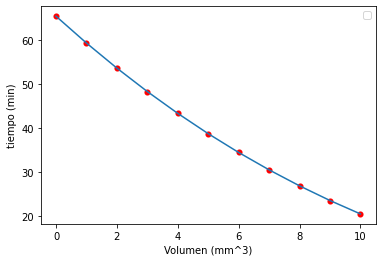

In [93]:
print('N=%i'%N,
      '--------------',
      T(N),sep='\n')